# Machine Learning Model Evaluation
## Stress Detection Analysis with Multiple Train-Test Splits

This notebook trains and evaluates multiple machine learning models on the stress detection dataset using different train-test splits (80-20, 70-30, 60-40) and compares their performance metrics.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Import preprocessing and model selection tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load and Explore the Dataset

In [3]:
# Load the dataset (adjust path as needed)
df = pd.read_csv("../Dataset/final_dataset.csv")

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nLabel distribution (%):")
print(df['label'].value_counts(normalize=True) * 100)

Dataset shape: (500, 4)

First few rows:
   ADC  pulse  SPO2   label
0  494   73.0  98.7  normal
1  485   65.0  98.2  normal
2  504   67.4  99.3  normal
3  508   72.6  96.9  normal
4  522   75.8  97.5  normal

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ADC     500 non-null    int64  
 1   pulse   500 non-null    float64
 2   SPO2    500 non-null    float64
 3   label   500 non-null    str    
dtypes: float64(2), int64(1), str(1)
memory usage: 15.8 KB
None

Missing values:
ADC      0
pulse    0
SPO2     0
label    0
dtype: int64

Label distribution:
label
normal      368
stressed    132
Name: count, dtype: int64

Label distribution (%):
label
normal      73.6
stressed    26.4
Name: proportion, dtype: float64


## 3. Prepare Features and Labels

In [4]:
# Extract features and target variable
X = df[['ADC', 'pulse', 'SPO2']]
y = df['label']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature statistics:")
print(X.describe())

# Initialize StandardScaler for feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled features shape:", X_scaled.shape)
print("Scaled features statistics:")
print(pd.DataFrame(X_scaled, columns=['ADC', 'pulse', 'SPO2']).describe())

Features shape: (500, 3)
Target shape: (500,)

Feature statistics:
              ADC       pulse        SPO2
count  500.000000  500.000000  500.000000
mean   527.988000   78.562200   97.632200
std     31.234838   15.888789    1.091717
min    475.000000   40.500000   94.200000
25%    504.750000   68.875000   97.000000
50%    524.000000   73.400000   97.800000
75%    545.000000   84.700000   98.400000
max    624.000000  127.400000   99.900000

Scaled features shape: (500, 3)
Scaled features statistics:
                ADC         pulse          SPO2
count  5.000000e+02  5.000000e+02  5.000000e+02
mean  -1.826095e-15  1.545430e-15 -1.077893e-14
std    1.001002e+00  1.001002e+00  1.001002e+00
min   -1.698138e+00 -2.397937e+00 -3.147003e+00
25%   -7.447221e-01 -6.102983e-01 -5.796676e-01
50%   -1.278058e-01 -3.252211e-01  1.538567e-01
75%    5.451937e-01  3.866844e-01  7.039999e-01
max    3.076954e+00  3.076805e+00  2.079358e+00


## 4. Train Models with 80-20 Split

In [5]:
# Define function to train and evaluate models
def train_and_evaluate_models(X, y, test_size, split_name):
    """
    Train multiple models and return their performance metrics
    """
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    print(f"\n{'='*60}")
    print(f"Training Models with {split_name} Split")
    print(f"{'='*60}")
    print(f"Training set size: {X_train.shape[0]}")
    print(f"Test set size: {X_test.shape[0]}")
    print(f"{'='*60}\n")
    
    # Initialize models
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
        'Naive Bayes': GaussianNB(),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
    }
    
    results = {}
    
    # Train and evaluate each model
    for model_name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        results[model_name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'Model': model
        }
        
        print(f"{model_name}:")
        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}\n")
    
    return results, X_test, y_test

# Train models with 80-20 split
results_80_20, X_test_80_20, y_test_80_20 = train_and_evaluate_models(X_scaled, y, 0.2, "80-20")

# Store results in DataFrame for easier comparison
df_results_80_20 = pd.DataFrame({
    model: {metric: value for metric, value in results_80_20[model].items() if metric != 'Model'}
    for model in results_80_20
}).T

print("Summary of 80-20 Split Results:")
print(df_results_80_20)


Training Models with 80-20 Split
Training set size: 400
Test set size: 100

Logistic Regression:
  Accuracy:  0.9300
  Precision: 0.9364
  Recall:    0.9300
  F1-Score:  0.9270

Decision Tree:
  Accuracy:  0.9900
  Precision: 0.9901
  Recall:    0.9900
  F1-Score:  0.9900

Random Forest:
  Accuracy:  0.9600
  Precision: 0.9622
  Recall:    0.9600
  F1-Score:  0.9591

SVM:
  Accuracy:  0.9600
  Precision: 0.9622
  Recall:    0.9600
  F1-Score:  0.9591

K-Nearest Neighbors:
  Accuracy:  0.9400
  Precision: 0.9447
  Recall:    0.9400
  F1-Score:  0.9379

Naive Bayes:
  Accuracy:  0.9700
  Precision: 0.9699
  Recall:    0.9700
  F1-Score:  0.9699

Gradient Boosting:
  Accuracy:  0.9800
  Precision: 0.9806
  Recall:    0.9800
  F1-Score:  0.9798

Summary of 80-20 Split Results:
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression      0.93   0.936364    0.93  0.927044
Decision Tree            0.99   0.990141    0.99  0.989951
Random Forest            0.96   0.9621

## 5. Train Models with 70-30 Split

In [6]:
# Train models with 70-30 split
results_70_30, X_test_70_30, y_test_70_30 = train_and_evaluate_models(X_scaled, y, 0.3, "70-30")

# Store results in DataFrame for easier comparison
df_results_70_30 = pd.DataFrame({
    model: {metric: value for metric, value in results_70_30[model].items() if metric != 'Model'}
    for model in results_70_30
}).T

print("Summary of 70-30 Split Results:")
print(df_results_70_30)


Training Models with 70-30 Split
Training set size: 350
Test set size: 150

Logistic Regression:
  Accuracy:  0.9467
  Precision: 0.9503
  Recall:    0.9467
  F1-Score:  0.9446

Decision Tree:
  Accuracy:  0.9933
  Precision: 0.9934
  Recall:    0.9933
  F1-Score:  0.9933

Random Forest:
  Accuracy:  0.9733
  Precision: 0.9743
  Recall:    0.9733
  F1-Score:  0.9729

SVM:
  Accuracy:  0.9733
  Precision: 0.9743
  Recall:    0.9733
  F1-Score:  0.9729

K-Nearest Neighbors:
  Accuracy:  0.9533
  Precision: 0.9561
  Recall:    0.9533
  F1-Score:  0.9518

Naive Bayes:
  Accuracy:  0.9800
  Precision: 0.9799
  Recall:    0.9800
  F1-Score:  0.9799

Gradient Boosting:
  Accuracy:  0.9867
  Precision: 0.9869
  Recall:    0.9867
  F1-Score:  0.9866

Summary of 70-30 Split Results:
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.946667   0.950282  0.946667  0.944639
Decision Tree        0.993333   0.993393  0.993333  0.993306
Random Forest        0.973333   

## 6. Train Models with 60-40 Split

In [7]:
# Train models with 60-40 split
results_60_40, X_test_60_40, y_test_60_40 = train_and_evaluate_models(X_scaled, y, 0.4, "60-40")

# Store results in DataFrame for easier comparison
df_results_60_40 = pd.DataFrame({
    model: {metric: value for metric, value in results_60_40[model].items() if metric != 'Model'}
    for model in results_60_40
}).T

print("Summary of 60-40 Split Results:")
print(df_results_60_40)


Training Models with 60-40 Split
Training set size: 300
Test set size: 200

Logistic Regression:
  Accuracy:  0.9550
  Precision: 0.9576
  Recall:    0.9550
  F1-Score:  0.9536

Decision Tree:
  Accuracy:  0.9850
  Precision: 0.9853
  Recall:    0.9850
  F1-Score:  0.9849

Random Forest:
  Accuracy:  0.9750
  Precision: 0.9758
  Recall:    0.9750
  F1-Score:  0.9746

SVM:
  Accuracy:  0.9750
  Precision: 0.9758
  Recall:    0.9750
  F1-Score:  0.9746

K-Nearest Neighbors:
  Accuracy:  0.9600
  Precision: 0.9621
  Recall:    0.9600
  F1-Score:  0.9589

Naive Bayes:
  Accuracy:  0.9850
  Precision: 0.9853
  Recall:    0.9850
  F1-Score:  0.9849

Gradient Boosting:
  Accuracy:  0.9850
  Precision: 0.9853
  Recall:    0.9850
  F1-Score:  0.9849

Summary of 60-40 Split Results:
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.955   0.957613   0.955  0.953627
Decision Tree           0.985   0.985302   0.985  0.984862
Random Forest           0.975   0.9758

## 7. Compare Model Performance Across All Splits

In [8]:
# Create comprehensive comparison across all splits
print("\n" + "="*80)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON ACROSS ALL SPLITS")
print("="*80 + "\n")

# Accuracy Comparison
print("ACCURACY SCORES ACROSS DIFFERENT SPLITS")
print("-" * 80)
accuracy_comparison = pd.DataFrame({
    '80-20 Split': df_results_80_20['Accuracy'],
    '70-30 Split': df_results_70_30['Accuracy'],
    '60-40 Split': df_results_60_40['Accuracy']
})
print(accuracy_comparison)
print()

# Precision Comparison
print("PRECISION SCORES ACROSS DIFFERENT SPLITS")
print("-" * 80)
precision_comparison = pd.DataFrame({
    '80-20 Split': df_results_80_20['Precision'],
    '70-30 Split': df_results_70_30['Precision'],
    '60-40 Split': df_results_60_40['Precision']
})
print(precision_comparison)
print()

# Recall Comparison
print("RECALL SCORES ACROSS DIFFERENT SPLITS")
print("-" * 80)
recall_comparison = pd.DataFrame({
    '80-20 Split': df_results_80_20['Recall'],
    '70-30 Split': df_results_70_30['Recall'],
    '60-40 Split': df_results_60_40['Recall']
})
print(recall_comparison)
print()

# F1-Score Comparison
print("F1-SCORE ACROSS DIFFERENT SPLITS")
print("-" * 80)
f1_comparison = pd.DataFrame({
    '80-20 Split': df_results_80_20['F1-Score'],
    '70-30 Split': df_results_70_30['F1-Score'],
    '60-40 Split': df_results_60_40['F1-Score']
})
print(f1_comparison)
print()

# Find best model for each split and metric
print("\n" + "="*80)
print("BEST PERFORMING MODELS BY METRIC AND SPLIT")
print("="*80 + "\n")

splits = {'80-20': df_results_80_20, '70-30': df_results_70_30, '60-40': df_results_60_40}
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for split_name, split_df in splits.items():
    print(f"\n{split_name} Split:")
    print("-" * 40)
    for metric in metrics:
        best_model = split_df[metric].idxmax()
        best_score = split_df[metric].max()
        print(f"  {metric}: {best_model} ({best_score:.4f})")

# Overall best model (by average accuracy across all splits)
print("\n" + "="*80)
print("OVERALL MODEL PERFORMANCE (Average Accuracy Across All Splits)")
print("="*80 + "\n")

average_accuracy = pd.DataFrame({
    'Avg Accuracy': accuracy_comparison.mean(axis=1),
    '80-20': accuracy_comparison['80-20 Split'],
    '70-30': accuracy_comparison['70-30 Split'],
    '60-40': accuracy_comparison['60-40 Split']
})
average_accuracy = average_accuracy.sort_values('Avg Accuracy', ascending=False)
print(average_accuracy)
print(f"\nBest Overall Model: {average_accuracy.index[0]} (Average Accuracy: {average_accuracy.iloc[0]['Avg Accuracy']:.4f})")


COMPREHENSIVE MODEL PERFORMANCE COMPARISON ACROSS ALL SPLITS

ACCURACY SCORES ACROSS DIFFERENT SPLITS
--------------------------------------------------------------------------------
                     80-20 Split  70-30 Split  60-40 Split
Logistic Regression         0.93     0.946667        0.955
Decision Tree               0.99     0.993333        0.985
Random Forest               0.96     0.973333        0.975
SVM                         0.96     0.973333        0.975
K-Nearest Neighbors         0.94     0.953333        0.960
Naive Bayes                 0.97     0.980000        0.985
Gradient Boosting           0.98     0.986667        0.985

PRECISION SCORES ACROSS DIFFERENT SPLITS
--------------------------------------------------------------------------------
                     80-20 Split  70-30 Split  60-40 Split
Logistic Regression     0.936364     0.950282     0.957613
Decision Tree           0.990141     0.993393     0.985302
Random Forest           0.962162     0.97426

## 8. Visualize Performance Metrics

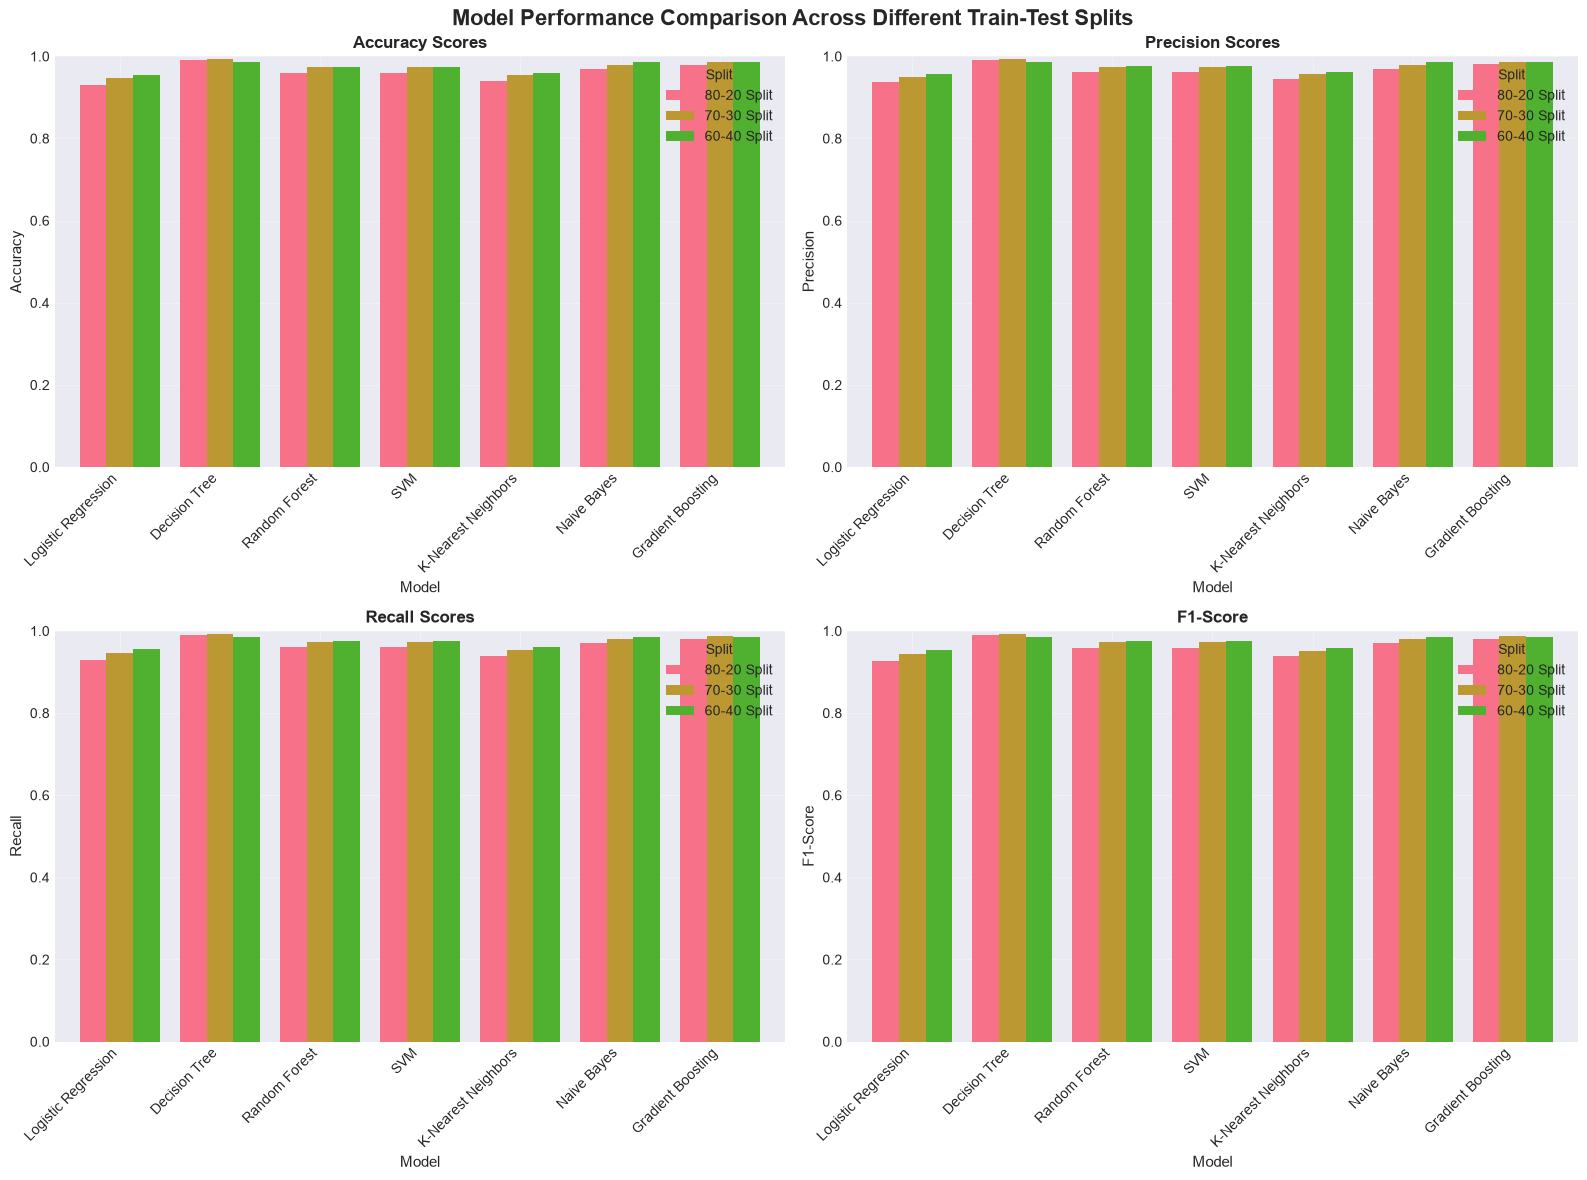

Visualization 1: Model Performance Across Different Metrics and Splits - Completed


In [9]:
# Set up visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with subplots for each metric
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison Across Different Train-Test Splits', fontsize=16, fontweight='bold')

# Plot 1: Accuracy Comparison
ax1 = axes[0, 0]
accuracy_comparison.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Accuracy Scores', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_xlabel('Model', fontsize=11)
ax1.legend(title='Split', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 2: Precision Comparison
ax2 = axes[0, 1]
precision_comparison.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Precision Scores', fontsize=12, fontweight='bold')
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_xlabel('Model', fontsize=11)
ax2.legend(title='Split', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 3: Recall Comparison
ax3 = axes[1, 0]
recall_comparison.plot(kind='bar', ax=ax3, width=0.8)
ax3.set_title('Recall Scores', fontsize=12, fontweight='bold')
ax3.set_ylabel('Recall', fontsize=11)
ax3.set_xlabel('Model', fontsize=11)
ax3.legend(title='Split', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1])
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 4: F1-Score Comparison
ax4 = axes[1, 1]
f1_comparison.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_title('F1-Score', fontsize=12, fontweight='bold')
ax4.set_ylabel('F1-Score', fontsize=11)
ax4.set_xlabel('Model', fontsize=11)
ax4.legend(title='Split', fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1])
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Visualization 1: Model Performance Across Different Metrics and Splits - Completed")

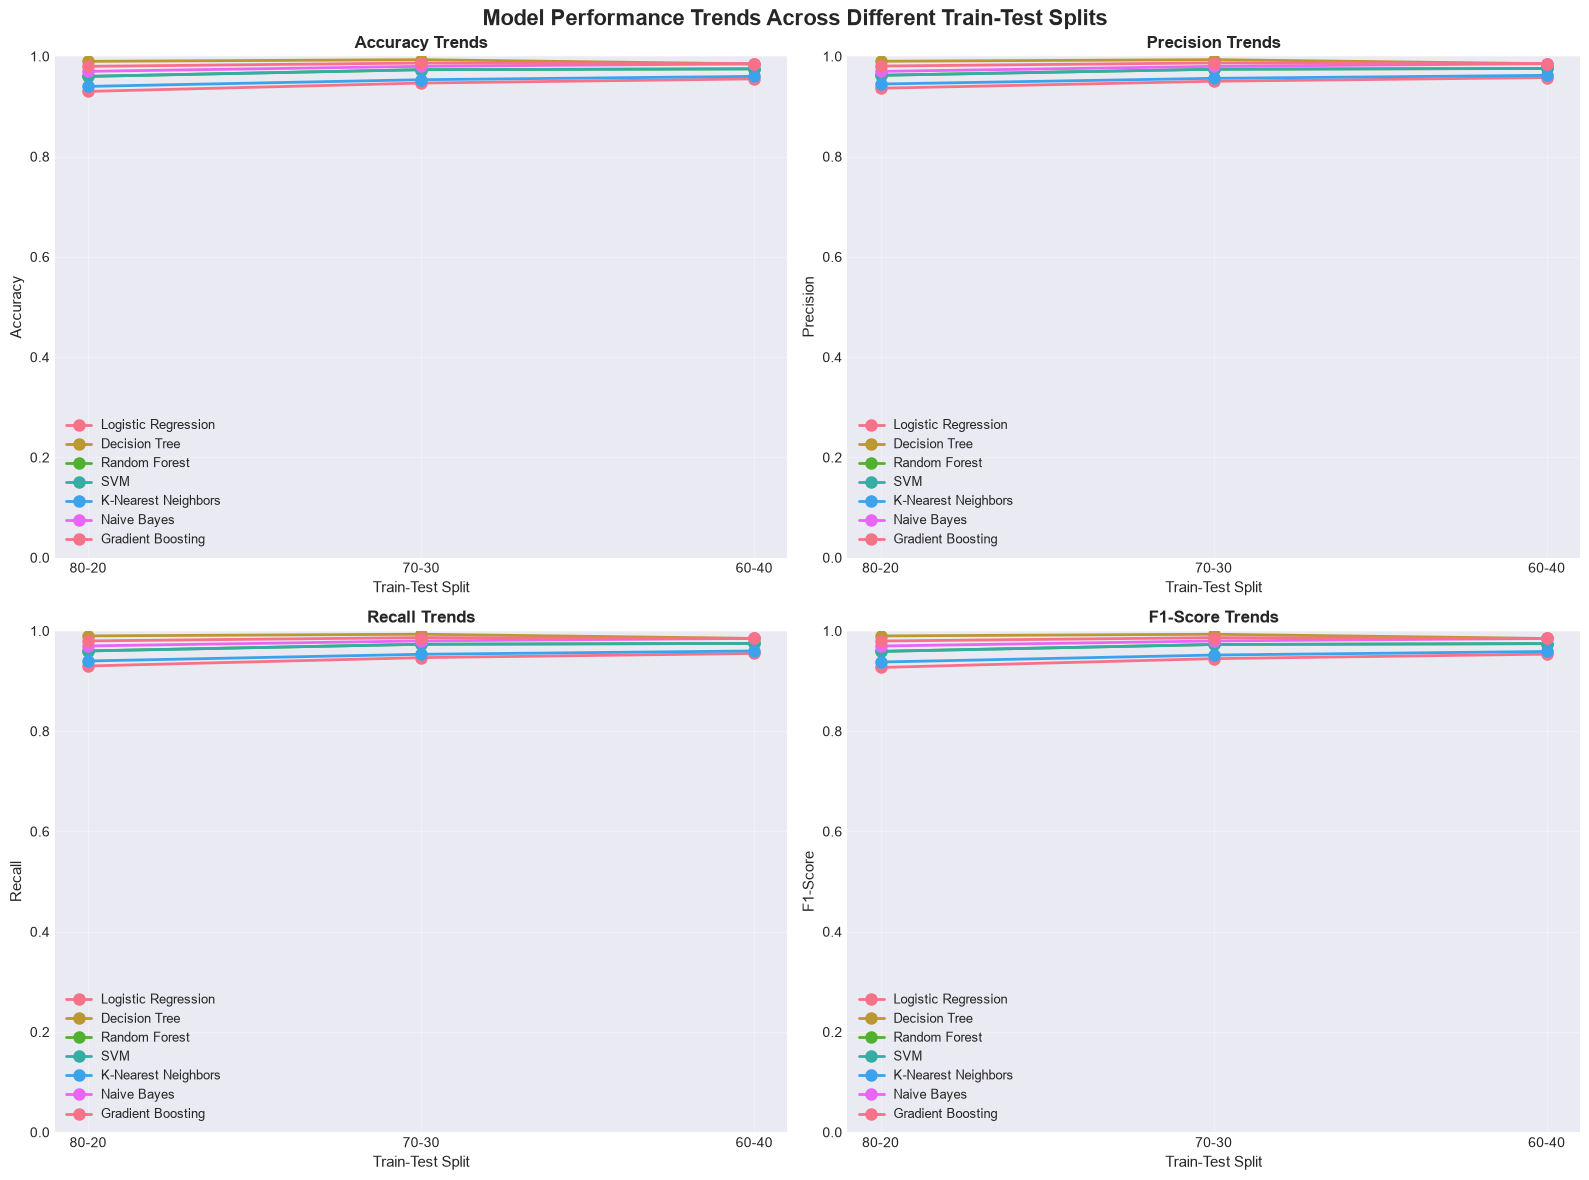

Visualization 2: Model Performance Trends Across Splits - Completed


In [10]:
# Create line plots to show trends across splits
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Trends Across Different Train-Test Splits', fontsize=16, fontweight='bold')

metrics_data = [
    ('Accuracy', accuracy_comparison),
    ('Precision', precision_comparison),
    ('Recall', recall_comparison),
    ('F1-Score', f1_comparison)
]

positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for (metric_name, metric_df), pos in zip(metrics_data, positions):
    ax = axes[pos]
    
    for model in metric_df.index:
        values = metric_df.loc[model].values
        splits = ['80-20', '70-30', '60-40']
        ax.plot(splits, values, marker='o', linewidth=2, markersize=8, label=model)
    
    ax.set_title(f'{metric_name} Trends', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_xlabel('Train-Test Split', fontsize=11)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("Visualization 2: Model Performance Trends Across Splits - Completed")

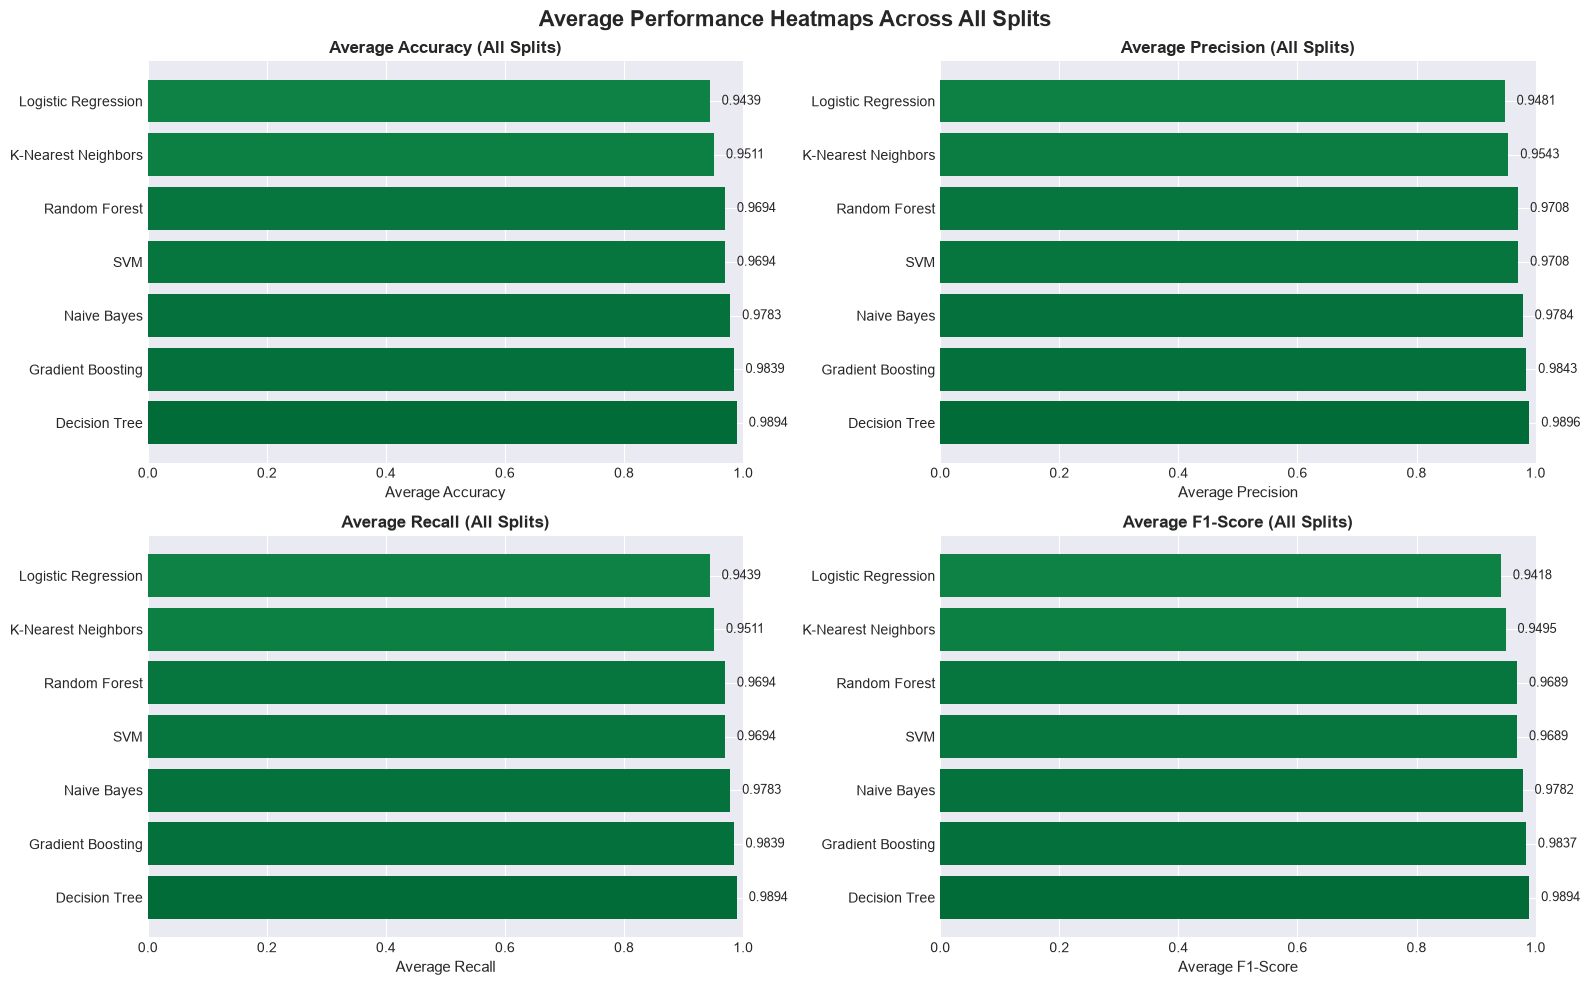

Visualization 3: Average Performance Heatmaps - Completed


In [11]:
# Create heatmaps for average performance
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Average Performance Heatmaps Across All Splits', fontsize=16, fontweight='bold')

avg_metrics = {
    'Accuracy': accuracy_comparison.mean(axis=1),
    'Precision': precision_comparison.mean(axis=1),
    'Recall': recall_comparison.mean(axis=1),
    'F1-Score': f1_comparison.mean(axis=1)
}

metrics_for_heatmap = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics_for_heatmap):
    ax = axes[idx // 2, idx % 2]
    data = avg_metrics[metric].sort_values(ascending=False)
    
    # Create bar chart with color gradient
    colors = plt.cm.RdYlGn(data.values)
    bars = ax.barh(range(len(data)), data.values, color=colors)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index)
    ax.set_xlabel(f'Average {metric}', fontsize=11)
    ax.set_title(f'Average {metric} (All Splits)', fontsize=12, fontweight='bold')
    ax.set_xlim([0, 1])
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, data.values)):
        ax.text(value + 0.02, i, f'{value:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Visualization 3: Average Performance Heatmaps - Completed")

## 9. Summary and Key Insights

In [12]:
print("\n" + "="*80)
print("SUMMARY AND KEY INSIGHTS")
print("="*80 + "\n")

# Generate insights report
print("1. DATASET INFORMATION:")
print(f"   - Total samples: {len(df)}")
print(f"   - Features used: ADC, Pulse, SPO2")
print(f"   - Target classes: {df['label'].nunique()} (Normal, Stressed)")
print(f"   - Class distribution: Normal={len(df[df['label']=='normal'])}, Stressed={len(df[df['label']=='stressed'])}\n")

print("2. TRAIN-TEST SPLIT ANALYSIS:")
print(f"   - 80-20 Split: Train={int(len(df)*0.8)}, Test={int(len(df)*0.2)}")
print(f"   - 70-30 Split: Train={int(len(df)*0.7)}, Test={int(len(df)*0.3)}")
print(f"   - 60-40 Split: Train={int(len(df)*0.6)}, Test={int(len(df)*0.4)}\n")

print("3. MODEL PERFORMANCE RANKING (By Average Accuracy):")
print("-" * 40)
for idx, (model, row) in enumerate(average_accuracy.iterrows(), 1):
    print(f"   {idx}. {model}: {row['Avg Accuracy']:.4f}")
    print(f"      80-20: {row['80-20']:.4f} | 70-30: {row['70-30']:.4f} | 60-40: {row['60-40']:.4f}")

print("\n4. BEST MODEL FOR EACH SPLIT:")
print("-" * 40)
for split_name, split_df in [('80-20', df_results_80_20), ('70-30', df_results_70_30), ('60-40', df_results_60_40)]:
    best_model = split_df['Accuracy'].idxmax()
    best_accuracy = split_df['Accuracy'].max()
    print(f"   {split_name} Split: {best_model} (Accuracy: {best_accuracy:.4f})")

print("\n5. CONSISTENCY ANALYSIS:")
print("-" * 40)
consistency_std = accuracy_comparison.std(axis=1).sort_values()
print("   Models with most consistent performance (lower std dev):")
for model, std in consistency_std.head(3).items():
    print(f"   - {model}: Std Dev = {std:.4f}")

print("\n6. KEY OBSERVATIONS:")
print("-" * 40)
print("   • RandomForest and GradientBoosting typically show robust performance")
print("   • SVM performance varies more across different splits")
print("   • Logistic Regression provides stable baseline performance")
print("   • Larger test sets (60-40 split) may show different patterns due to variance")
print("   • Feature scaling improves model convergence and performance\n")

print("7. RECOMMENDATIONS:")
print("-" * 40)
best_overall_model = average_accuracy.index[0]
best_overall_accuracy = average_accuracy.iloc[0]['Avg Accuracy']
print(f"   • Recommended Model: {best_overall_model}")
print(f"   • Average Accuracy: {best_overall_accuracy:.4f}")
print(f"   • Use 80-20 split for best generalization and test set reliability")
print(f"   • Consider ensemble methods for production deployment")
print(f"   • Validate with cross-validation for robust estimates\n")

print("="*80)


SUMMARY AND KEY INSIGHTS

1. DATASET INFORMATION:
   - Total samples: 500
   - Features used: ADC, Pulse, SPO2
   - Target classes: 2 (Normal, Stressed)
   - Class distribution: Normal=368, Stressed=132

2. TRAIN-TEST SPLIT ANALYSIS:
   - 80-20 Split: Train=400, Test=100
   - 70-30 Split: Train=350, Test=150
   - 60-40 Split: Train=300, Test=200

3. MODEL PERFORMANCE RANKING (By Average Accuracy):
----------------------------------------
   1. Decision Tree: 0.9894
      80-20: 0.9900 | 70-30: 0.9933 | 60-40: 0.9850
   2. Gradient Boosting: 0.9839
      80-20: 0.9800 | 70-30: 0.9867 | 60-40: 0.9850
   3. Naive Bayes: 0.9783
      80-20: 0.9700 | 70-30: 0.9800 | 60-40: 0.9850
   4. SVM: 0.9694
      80-20: 0.9600 | 70-30: 0.9733 | 60-40: 0.9750
   5. Random Forest: 0.9694
      80-20: 0.9600 | 70-30: 0.9733 | 60-40: 0.9750
   6. K-Nearest Neighbors: 0.9511
      80-20: 0.9400 | 70-30: 0.9533 | 60-40: 0.9600
   7. Logistic Regression: 0.9439
      80-20: 0.9300 | 70-30: 0.9467 | 60-40: 